# Phase 6: Deployment

**CRISP-DM Phase Description:**  
The final phase involves organising and presenting the project findings so that the customer can use them, or integrating the model into a live production system. Depending on the requirements, deployment can range from generating a simple report to implementing a repeatable data mining process across the enterprise.

---

In [1]:
# Standard imports
import pandas as pd
import numpy as np
import json

---
### Task 1: Plan Deployment

Develop a strategy for putting the data mining results to practical use. This includes:

- **Deployment Strategy:** How will the model be consumed? Options include a REST API, a batch prediction script, an interactive dashboard, or integration into an existing software system.
- **Infrastructure Requirements:** What technical environment is needed (e.g., cloud services, web server, containerisation)?
- **Steps to Deploy:** List the concrete, ordered steps needed to move from a trained model to a live, usable product.
- **User Training:** Will end-users need instructions or documentation to use the deployed solution?

**Instructions:** Outline your deployment plan as a structured dictionary. If building an API or script, sketch the basic structure in code.

In [2]:
# Plan the deployment of your model/solution.

deployment_plan = {
    "strategy": "Interactive Streamlit web application",

    "infrastructure": [
        "Local Python environment for development and testing",
        "GitHub repository for version control and project hosting",
        "Streamlit Community Cloud for deployment"
    ],

    "deployment_steps": [
        "Step 1: Save the final trained Random Forest model using joblib or pickle",
        "Step 2: Create a Streamlit application interface for user input and prediction output",
        "Step 3: Load the saved model inside the Streamlit app",
        "Step 4: Collect user inputs for the required project features",
        "Step 5: Apply the same preprocessing or formatting used during training",
        "Step 6: Generate the prediction and display the result in the web app",
        "Step 7: Upload the app files, model file, and requirements.txt to GitHub",
        "Step 8: Deploy the application using Streamlit Community Cloud",
        "Step 9: Test the deployed app using sample inputs"
    ],

    "user_documentation": "A short user guide will be provided explaining how to enter project details, run the prediction, and interpret the approval result.",

    "target_audience": "End-users such as reviewers, administrators, or decision-makers using the web app to support grant application screening"
}

In [3]:
import joblib
import pandas as pd

# Load model
MODEL_PATH = "random_forest_model.pkl"
model = joblib.load(MODEL_PATH)

print(f"Model loaded from: {MODEL_PATH}")

Model loaded from: random_forest_model.pkl


In [4]:
# Optional: Sketch a basic deployment script or API structure

import joblib
import pandas as pd

# Load the trained model saved earlier from Phase 4
MODEL_PATH = "random_forest_model.pkl"
model = joblib.load(MODEL_PATH)

print(f"Model loaded from: {MODEL_PATH}")


# Prediction function
def predict(input_data: dict) -> dict:
    """
    Takes a dictionary of feature values
    and returns the model's prediction.
    """

    # Convert input into DataFrame
    input_df = pd.DataFrame([input_data])

    # Make prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]

    return {
        "prediction": int(prediction),
        "approval_probability": float(probability)
    }

Model loaded from: random_forest_model.pkl


In [5]:
# Display the deployment plan
print(json.dumps(deployment_plan, indent=2))

{
  "strategy": "Interactive Streamlit web application",
  "infrastructure": [
    "Local Python environment for development and testing",
    "GitHub repository for version control and project hosting",
    "Streamlit Community Cloud for deployment"
  ],
  "deployment_steps": [
    "Step 1: Save the final trained Random Forest model using joblib or pickle",
    "Step 2: Create a Streamlit application interface for user input and prediction output",
    "Step 3: Load the saved model inside the Streamlit app",
    "Step 4: Collect user inputs for the required project features",
    "Step 5: Apply the same preprocessing or formatting used during training",
    "Step 6: Generate the prediction and display the result in the web app",
    "Step 7: Upload the app files, model file, and requirements.txt to GitHub",
    "Step 8: Deploy the application using Streamlit Community Cloud",
    "Step 9: Test the deployed app using sample inputs"
  ],
  "user_documentation": "A short user guide will 

---
### Task 2: Plan Monitoring and Maintenance

A deployed model is not "set and forget". Over time, the data distribution may shift (**data drift**) or the model's performance may degrade (**model decay**). This task creates a monitoring and maintenance plan:

- **Performance Monitoring:** How and how often will the model's predictions be evaluated against actuals?
- **Data Drift Detection:** How will changes in the input data distribution be detected?
- **Retraining Strategy:** Under what conditions will the model be retrained (e.g., scheduled, triggered by performance drop)?
- **Logging and Alerting:** What will be logged, and what triggers an alert?

**Instructions:** Document your monitoring and maintenance plan.

In [6]:
# Plan monitoring and maintenance.

monitoring_plan = {
    "performance_monitoring": {
        "frequency": "Monthly",
        "metrics_tracked": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
        "method": "Compare model predictions with actual approval outcomes once new labelled data becomes available"
    },

    "data_drift_detection": {
        "method": "Track changes in feature distributions and compare them with the training data using summary statistics and visual inspection",
        "frequency": "Monthly",
        "threshold": "Investigate if major feature distributions change noticeably or if model performance drops significantly"
    },

    "retraining_strategy": {
        "trigger": "Retrain if F1-score or recall drops noticeably, or if significant data drift is detected",
        "data_source": "Most recent labelled grant application data collected after deployment",
        "responsible_team": "Project developer or system administrator"
    },

    "logging": {
        "what_to_log": [
            "Input feature values",
            "Predicted class",
            "Prediction probability",
            "Timestamp of prediction",
            "System errors or failed predictions"
        ],
        "alert_conditions": [
            "Repeated prediction errors",
            "Noticeable drop in model performance",
            "Large changes in input feature distributions"
        ]
    }
}

In [7]:
# Display the monitoring plan
print(json.dumps(monitoring_plan, indent=2))

{
  "performance_monitoring": {
    "frequency": "Monthly",
    "metrics_tracked": [
      "Accuracy",
      "Precision",
      "Recall",
      "F1-score",
      "ROC-AUC"
    ],
    "method": "Compare model predictions with actual approval outcomes once new labelled data becomes available"
  },
  "data_drift_detection": {
    "method": "Track changes in feature distributions and compare them with the training data using summary statistics and visual inspection",
    "frequency": "Monthly",
    "threshold": "Investigate if major feature distributions change noticeably or if model performance drops significantly"
  },
  "retraining_strategy": {
    "trigger": "Retrain if F1-score or recall drops noticeably, or if significant data drift is detected",
    "data_source": "Most recent labelled grant application data collected after deployment",
    "responsible_team": "Project developer or system administrator"
  },
  "logging": {
    "what_to_log": [
      "Input feature values",
      "Pr

---
### Task 3: Produce Final Report

Compile a final summary of the entire project. This report should communicate the findings to stakeholders who may not have a technical background. It typically includes:

- **Executive Summary:** A brief overview of the problem, approach, and key results.
- **Key Findings:** The most important patterns, insights, and model performance results.
- **Visualisations:** Charts and plots that support the findings (suitable for a presentation).
- **Recommendations:** Actionable recommendations based on the analysis.
- **Limitations:** Known limitations and caveats of the analysis.

**Instructions:** Draft the final report content below. Include any code needed to generate summary visualisations.

In [8]:
# Draft the final report as a structured document.

final_report = {
    "title": "Grant Application Screening Using Machine Learning",

    "executive_summary": "This project developed a machine learning solution to support the screening of grant applications by predicting whether a project is likely to be approved. Historical application data was analysed using the CRISP-DM methodology, covering business understanding, data exploration, preparation, modelling, evaluation, and deployment planning. After comparing multiple classification models, Random Forest was selected as the final model. The results show that the model performs well in identifying approved projects and can support decision-making by helping prioritise applications. Although the model is affected by class imbalance and has limited ability to identify non-approved projects, it still provides useful value as a decision-support tool. A deployment plan using Streamlit was also proposed to make the model accessible through a simple web-based interface.",

    "key_findings": [
        "The dataset was highly imbalanced, with approved projects representing the majority of cases.",
        "Teacher experience, project category, and submission timing were useful features for prediction.",
        "Text-based features did not show strong visible differences between approved and non-approved projects and were excluded from the final model.",
        "Random Forest provided the most practical and balanced performance among the tested models.",
        "Class imbalance remained a key limitation and influenced model behaviour, particularly for the minority class."
    ],

    "model_performance": {
        "best_model": "Random Forest",
        "key_metric": "F1-score",
        "key_metric_value": 0.8994
    },

    "recommendations": [
        "Use the Random Forest model as a decision-support tool rather than a replacement for human judgement.",
        "Deploy the model through a Streamlit web application for simple and interactive use.",
        "Monitor performance regularly after deployment to detect drift or declining accuracy.",
        "Improve future versions of the model by applying stronger imbalance-handling techniques and additional feature engineering."
    ],

    "limitations": [
        "The dataset is imbalanced, which affects the model’s ability to classify non-approved projects accurately.",
        "ROC-AUC scores indicate limited separation between approved and non-approved classes.",
        "The deployed model should be used to support human decision-making, not fully automate approval decisions."
    ]
}

In [9]:
# Display the final report
print("=" * 60)
print(f"FINAL REPORT: {final_report['title']}")
print("=" * 60)

print(f"\n--- Executive Summary ---")
print(final_report['executive_summary'])

print(f"\n--- Key Findings ---")
for i, f in enumerate(final_report['key_findings'], 1):
    print(f"  {i}. {f}")

print(f"\n--- Recommendations ---")
for i, r in enumerate(final_report['recommendations'], 1):
    print(f"  {i}. {r}")

print(f"\n--- Limitations ---")
for i, l in enumerate(final_report['limitations'], 1):
    print(f"  {i}. {l}")

FINAL REPORT: Grant Application Screening Using Machine Learning

--- Executive Summary ---
This project developed a machine learning solution to support the screening of grant applications by predicting whether a project is likely to be approved. Historical application data was analysed using the CRISP-DM methodology, covering business understanding, data exploration, preparation, modelling, evaluation, and deployment planning. After comparing multiple classification models, Random Forest was selected as the final model. The results show that the model performs well in identifying approved projects and can support decision-making by helping prioritise applications. Although the model is affected by class imbalance and has limited ability to identify non-approved projects, it still provides useful value as a decision-support tool. A deployment plan using Streamlit was also proposed to make the model accessible through a simple web-based interface.

--- Key Findings ---
  1. The dataset

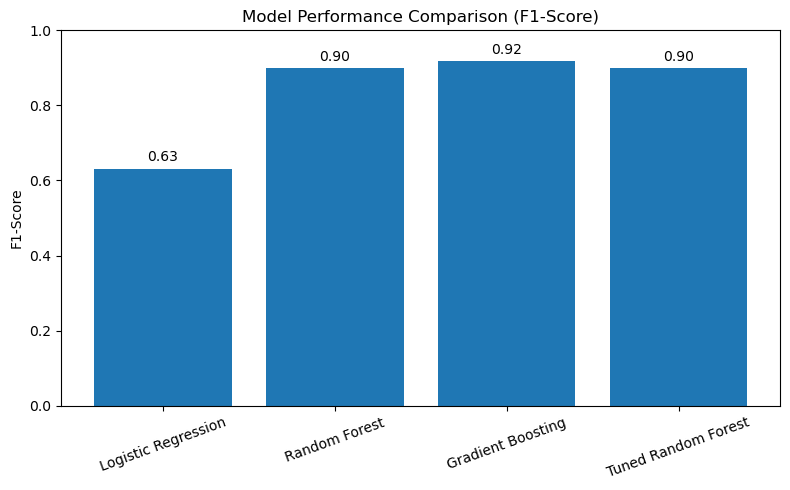

In [10]:
# Optional: Generate summary visualisations for the stakeholder presentation

import matplotlib.pyplot as plt

# Your actual model names
models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosting",
    "Tuned Random Forest"
]

# Use your F1-scores (from your results)
scores = [0.6317, 0.8994, 0.9176, 0.8994]

plt.figure(figsize=(8, 5))
plt.bar(models, scores)

plt.title("Model Performance Comparison (F1-Score)")
plt.ylabel("F1-Score")
plt.ylim(0, 1)

# Add values on top of bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

---
### Task 4: Review Project

Conduct a project retrospective. Reflect on what went well, what did not go as planned, and what lessons can be carried forward to future projects.

- **What went well?** Successes, effective techniques, good decisions.
- **What could be improved?** Challenges, mistakes, or inefficiencies encountered.
- **Lessons learned:** Key takeaways for future data science projects.
- **Skills developed:** New skills or knowledge gained during the project.

**Instructions:** Complete the project retrospective below.

In [11]:
# Conduct the project retrospective.

project_retrospective = {
    "went_well": [
        "The CRISP-DM structure helped organise the project clearly from business understanding through deployment planning.",
        "Data preparation was completed successfully, including cleaning, encoding, datetime feature extraction, outlier handling, and formatting.",
        "Multiple models were trained and compared, which made the final model selection more reliable.",
        "The Random Forest model provided practical performance and was suitable for use as a decision-support tool."
    ],

    "could_improve": [
        "The dataset was highly imbalanced, which reduced the model’s ability to classify non-approved projects accurately.",
        "Text features were difficult to use effectively without more advanced natural language processing methods.",
        "More time could have been spent on improving minority-class detection and experimenting with additional imbalance-handling techniques."
    ],

    "lessons_learned": [
        "High accuracy does not always mean a model is good, especially when the dataset is imbalanced.",
        "Confusion matrices and class-specific metrics are essential for understanding real model behaviour.",
        "Feature engineering and correct preprocessing are critical to making machine learning models work effectively.",
        "Model evaluation should always be linked back to business objectives, not only technical metrics."
    ],

    "skills_developed": [
        "Data cleaning and preprocessing using pandas",
        "Feature engineering, encoding, and outlier handling",
        "Model training and comparison using scikit-learn",
        "Model evaluation using confusion matrices, F1-score, and ROC-AUC",
        "Deployment planning using Streamlit and model serialization with joblib"
    ]
}

In [12]:
# Display the retrospective
print("=" * 60)
print("PROJECT RETROSPECTIVE")
print("=" * 60)

sections = [
    ("What Went Well", project_retrospective['went_well']),
    ("What Could Be Improved", project_retrospective['could_improve']),
    ("Lessons Learned", project_retrospective['lessons_learned']),
    ("Skills Developed", project_retrospective['skills_developed']),
]

for section_name, items in sections:
    print(f"\n--- {section_name} ---")
    if items:
        for item in items:
            print(f"  - {item}")
    else:
        print("  [Not yet documented]")

PROJECT RETROSPECTIVE

--- What Went Well ---
  - The CRISP-DM structure helped organise the project clearly from business understanding through deployment planning.
  - Data preparation was completed successfully, including cleaning, encoding, datetime feature extraction, outlier handling, and formatting.
  - Multiple models were trained and compared, which made the final model selection more reliable.
  - The Random Forest model provided practical performance and was suitable for use as a decision-support tool.

--- What Could Be Improved ---
  - The dataset was highly imbalanced, which reduced the model’s ability to classify non-approved projects accurately.
  - Text features were difficult to use effectively without more advanced natural language processing methods.
  - More time could have been spent on improving minority-class detection and experimenting with additional imbalance-handling techniques.

--- Lessons Learned ---
  - High accuracy does not always mean a model is good,

_________________________________________________________________________________

### Project Review

Overall, the project was successful in following the CRISP-DM process from problem definition to deployment planning. Strong progress was made in data preparation, feature engineering, model training, and evaluation. One of the main strengths of the project was the structured comparison of multiple models, which supported a more informed final model choice. However, the project also highlighted challenges such as class imbalance and limited separation between approved and non-approved projects. These issues affected model performance, particularly on the minority class. Important lessons learned include the need to look beyond accuracy, the value of confusion matrices and F1-score, and the importance of linking technical results back to business objectives. The project also helped develop practical skills in preprocessing, model tuning, evaluation, and deployment planning.

---

## Key Takeaway on Iteration

While the six CRISP-DM phases are presented **sequentially** in these notebooks, in practice the process is **highly iterative**. Real-world data science projects rarely follow a straight line from Phase 1 to Phase 6.

Common iteration patterns include:

- **Modelling → Data Preparation:** If the model performs poorly, you may return to Phase 3 to engineer new features, clean data differently, or acquire more data.
- **Evaluation → Modelling:** If the model does not meet the business success criteria, you may go back to Phase 4 to try different algorithms or tune hyperparameters.
- **Deployment → Evaluation:** If the deployed model underperforms in production (data drift), you may return to Phase 5 to re-evaluate and then to Phase 3/4 to retrain.
- **Any Phase → Business Understanding:** New findings in later phases may redefine the business objectives or success criteria originally set in Phase 1.

```
┌───────────────────────────────────────────────────────────┐
│                     CRISP-DM Lifecycle                    │
│                                                           │
│   Phase 1 ──► Phase 2 ──► Phase 3 ──► Phase 4            │
│   Business    Data        Data        Modelling           │
│   Under.      Under.      Prep.           │               │
│     ▲                       ▲              │               │
│     │                       │              ▼               │
│     │                       └──────── Phase 5             │
│     │                                Evaluation           │
│     │                                    │                │
│     │                                    ▼                │
│     └──────────────────────────────  Phase 6              │
│                                     Deployment            │
└───────────────────────────────────────────────────────────┘
```

> **Remember:** Iteration is not failure — it is the *expected* workflow. Each cycle through the process deepens your understanding of both the data and the business problem, ultimately leading to a better solution.